In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
artists = pd.read_csv("../data/artists.csv")

prepared = pd.read_csv("../data/artists_prepared_for_wikidata.csv")

enriched = pd.read_csv("../data/data_artists_enriched.csv")

In [3]:
print("Original MoMA dataset:", len(artists))
print("Artists requiring enrichment:", len(prepared))
print("Enriched dataset:", len(enriched))

Original MoMA dataset: 15091
Artists requiring enrichment: 10525
Enriched dataset: 10525


In [4]:
match_counts = enriched["match_status"].value_counts()

match_counts

match_status
matched      5186
not_found    3375
uncertain    1944
error          20
Name: count, dtype: int64

In [5]:
match_percent = (
    enriched["match_status"]
    .value_counts(normalize=True)
    * 100
).round(2)

match_percent

match_status
matched      49.27
not_found    32.07
uncertain    18.47
error         0.19
Name: proportion, dtype: float64

In [6]:
birth_before = prepared["Birth Year"].notna().sum()

birth_before

np.int64(6671)

In [7]:
birth_after = enriched["Birth Year"].notna().sum()

birth_after

np.int64(7171)

In [8]:
birth_added = birth_after - birth_before

print("Birth years added:", birth_added)

Birth years added: 500


In [9]:
death_before = prepared["Death Year"].notna().sum()

death_after = enriched["Death Year"].notna().sum()

death_added = death_after - death_before

print("Death years added:", death_added)

Death years added: 1234


In [10]:
columns = [
    "Name",
    "Nationality",
    "Gender",
    "Birth Year",
    "Death Year"
]

before_complete = []

after_complete = []

for col in columns:

    before_complete.append(
        prepared[col].notna().mean()*100
    )

    after_complete.append(
        enriched[col].notna().mean()*100
    )

comparison = pd.DataFrame({

    "Field":columns,

    "Before (%)":np.round(before_complete,2),

    "After (%)":np.round(after_complete,2)

})

comparison

,Field,Before (%),After (%)
0,Name,100.00,100.00
1,Nationality,76.86,76.86
2,Gender,71.80,71.80
3,Birth Year,63.38,68.13
4,Death Year,0.12,11.85


In [11]:
summary = {

    "Original artists":len(artists),

    "Artists requiring enrichment":len(prepared),

    "Matched artists":(enriched["match_status"]=="matched").sum(),

    "Birth years added":birth_added,

    "Death years added":death_added

}

summary

{'Original artists': 15091,
 'Artists requiring enrichment': 10525,
 'Matched artists': np.int64(5186),
 'Birth years added': np.int64(500),
 'Death years added': np.int64(1234)}

In [12]:
results = pd.DataFrame({

    "Metric":[

        "Original dataset",

        "Artists requiring enrichment",

        "Successful matches",

        "Birth years added",

        "Death years added"

    ],

    "Value":[

        len(artists),

        len(prepared),

        (enriched["match_status"]=="matched").sum(),

        birth_added,

        death_added

    ]

})

results

,Metric,Value
0,Original dataset,15091
1,Artists requiring enrichment,10525
2,Successful matches,5186
3,Birth years added,500
4,Death years added,1234


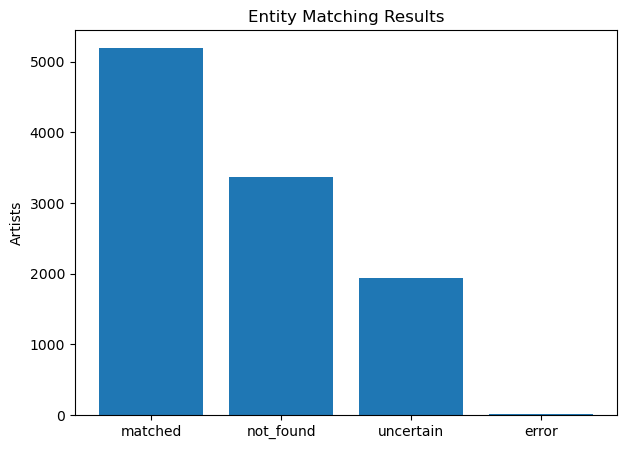

In [13]:
match_counts = enriched["match_status"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(match_counts.index, match_counts.values)

plt.title("Entity Matching Results")

plt.ylabel("Artists")

plt.show()

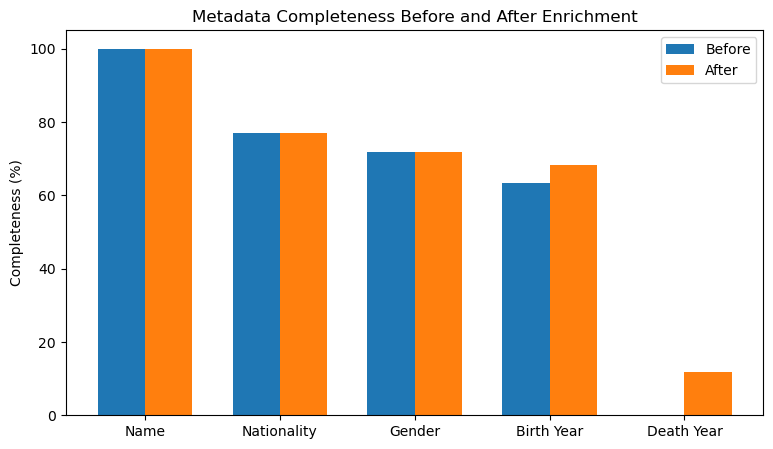

In [14]:
x = np.arange(len(columns))

width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x-width/2, before_complete, width, label="Before")

plt.bar(x+width/2, after_complete, width, label="After")

plt.xticks(x, columns)

plt.ylabel("Completeness (%)")

plt.title("Metadata Completeness Before and After Enrichment")

plt.legend()

plt.show()

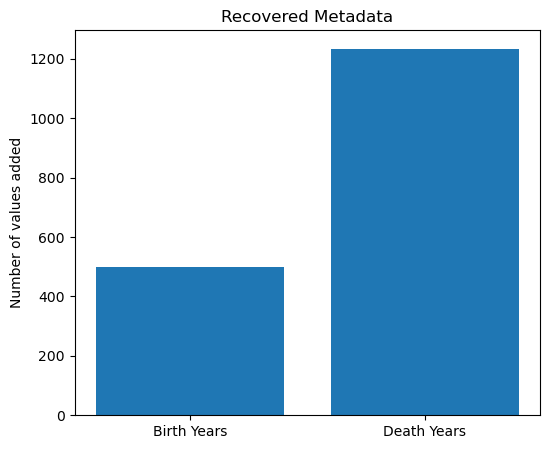

In [15]:
labels = ["Birth Years", "Death Years"]

values = [birth_added, death_added]

plt.figure(figsize=(6,5))

plt.bar(labels, values)

plt.title("Recovered Metadata")

plt.ylabel("Number of values added")

plt.show()

In [16]:
matched = (enriched["match_status"]=="matched").sum()

success = matched/len(prepared)*100

print(f"Overall match rate: {success:.2f}%")

Overall match rate: 49.27%


In [17]:
print("="*40)

print("FINAL PROJECT RESULTS")

print("="*40)

print(f"Original dataset: {len(artists):,}")

print(f"Artists requiring enrichment: {len(prepared):,}")

print(f"Successful matches: {matched:,}")

print(f"Birth years added: {birth_added:,}")

print(f"Death years added: {death_added:,}")

print(f"Overall match rate: {success:.2f}%")

print("="*40)

FINAL PROJECT RESULTS
Original dataset: 15,091
Artists requiring enrichment: 10,525
Successful matches: 5,186
Birth years added: 500
Death years added: 1,234
Overall match rate: 49.27%


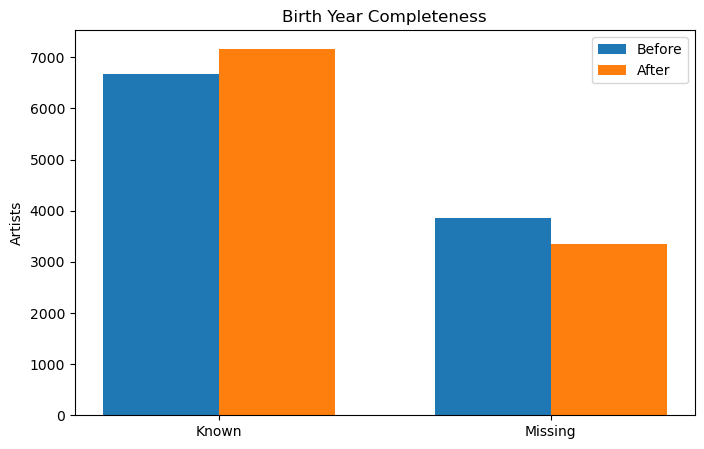

In [18]:
birth_before_known = prepared["Birth Year"].notna().sum()
birth_before_missing = prepared["Birth Year"].isna().sum()

birth_after_known = enriched["Birth Year"].notna().sum()
birth_after_missing = enriched["Birth Year"].isna().sum()

labels = ["Known", "Missing"]

before = [birth_before_known, birth_before_missing]
after = [birth_after_known, birth_after_missing]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, before, width, label="Before")
plt.bar(x+width/2, after, width, label="After")

plt.xticks(x, labels)

plt.ylabel("Artists")

plt.title("Birth Year Completeness")

plt.legend()

plt.show()

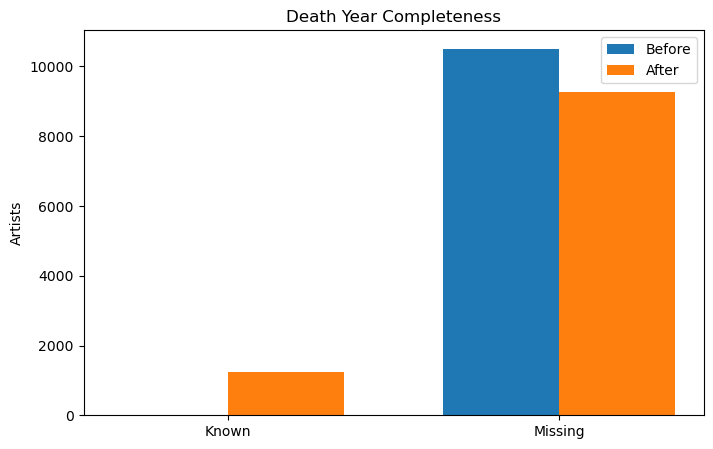

In [19]:
death_before_known = prepared["Death Year"].notna().sum()
death_before_missing = prepared["Death Year"].isna().sum()

death_after_known = enriched["Death Year"].notna().sum()
death_after_missing = enriched["Death Year"].isna().sum()

labels = ["Known", "Missing"]

before = [death_before_known, death_before_missing]
after = [death_after_known, death_after_missing]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, before, width, label="Before")
plt.bar(x+width/2, after, width, label="After")

plt.xticks(x, labels)

plt.ylabel("Artists")

plt.title("Death Year Completeness")

plt.legend()

plt.show()

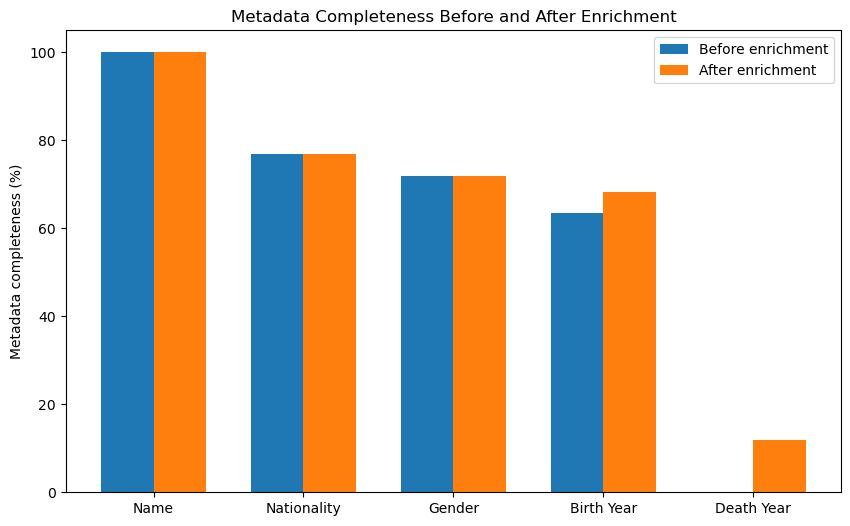

In [20]:
columns = [
    "Name",
    "Nationality",
    "Gender",
    "Birth Year",
    "Death Year"
]

before = []
after = []

for col in columns:

    before.append(prepared[col].notna().mean()*100)

    after.append(enriched[col].notna().mean()*100)

x = np.arange(len(columns))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x-width/2, before, width, label="Before enrichment")

plt.bar(x+width/2, after, width, label="After enrichment")

plt.xticks(x, columns)

plt.ylabel("Metadata completeness (%)")

plt.ylim(0,105)

plt.title("Metadata Completeness Before and After Enrichment")

plt.legend()

plt.show()

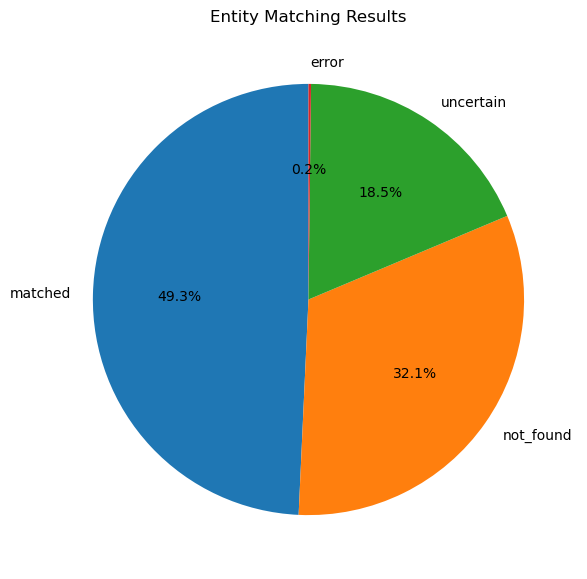

In [21]:
status = enriched["match_status"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    status.values,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Entity Matching Results")

plt.show()

In [22]:
gender_match = (
    enriched
    .groupby(["Gender","match_status"])
    .size()
    .unstack(fill_value=0)
)

gender_match

match_status,error,matched,not_found,uncertain
Gender,,,,
Female,2,1161,338,186
Male,12,3663,1241,949
male,0,2,3,0


In [23]:
gender_percent = (
    gender_match.div(gender_match.sum(axis=1), axis=0)*100
).round(2)

gender_percent

match_status,error,matched,not_found,uncertain
Gender,,,,
Female,0.12,68.82,20.04,11.03
Male,0.20,62.46,21.16,16.18
male,0.00,40.00,60.00,0.00


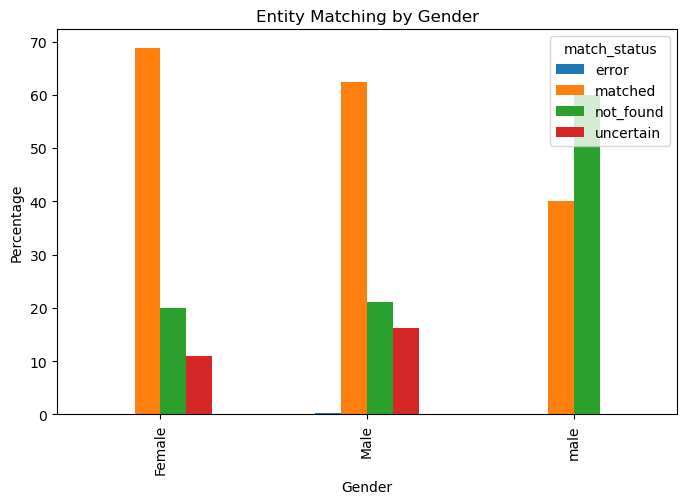

In [24]:
gender_percent.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Percentage")
plt.title("Entity Matching by Gender")

plt.show()

In [25]:
nationality = (
    enriched
    .groupby(["Nationality","match_status"])
    .size()
    .unstack(fill_value=0)
)

In [26]:
nationality = nationality[nationality.sum(axis=1)>=30]

In [27]:
nationality_percent = (
    nationality.div(nationality.sum(axis=1),axis=0)
    *100
).round(1)

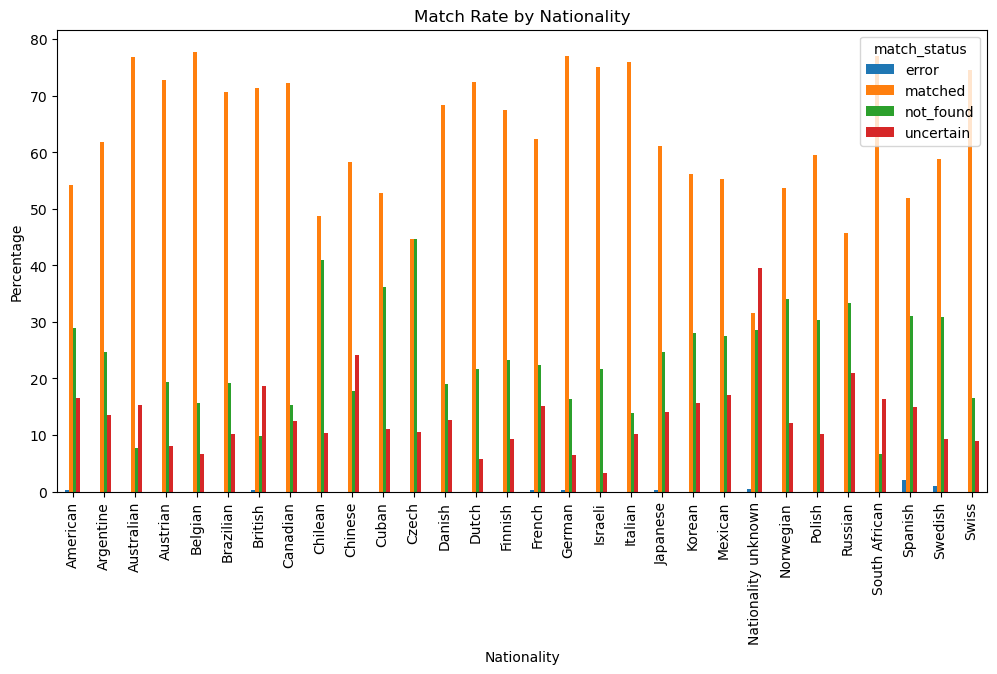

In [28]:
nationality_percent.plot(
    kind="bar",
    figsize=(12,6)
)

plt.ylabel("Percentage")
plt.title("Match Rate by Nationality")

plt.show()

In [29]:
summary = pd.DataFrame({

"Metadata":[
"Birth Year",
"Death Year"
],

"Recovered":[
birth_added,
death_added
]

})

summary

,Metadata,Recovered
0,Birth Year,500
1,Death Year,1234


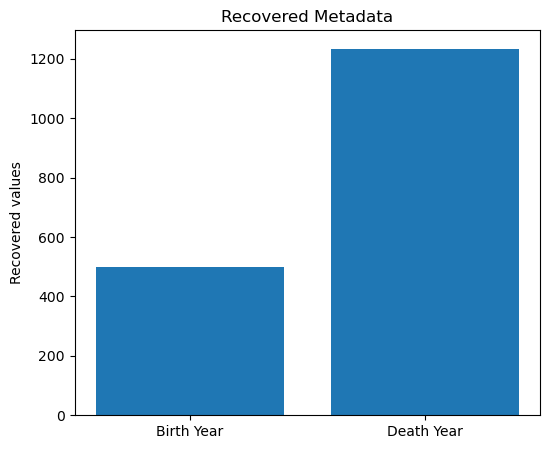

In [30]:
plt.figure(figsize=(6,5))

plt.bar(summary["Metadata"],summary["Recovered"])

plt.ylabel("Recovered values")

plt.title("Recovered Metadata")

plt.show()

In [31]:
fields = [
"Name",
"Nationality",
"Gender",
"Birth Year",
"Death Year"
]

before=[]

after=[]

for field in fields:

    before.append(prepared[field].notna().mean()*100)

    after.append(enriched[field].notna().mean()*100)

comparison=pd.DataFrame({

"Field":fields,

"Before":before,

"After":after

})

comparison

,Field,Before,After
0,Name,100.000000,100.000000
1,Nationality,76.855107,76.855107
2,Gender,71.800475,71.800475
3,Birth Year,63.382423,68.133017
4,Death Year,0.123515,11.847981


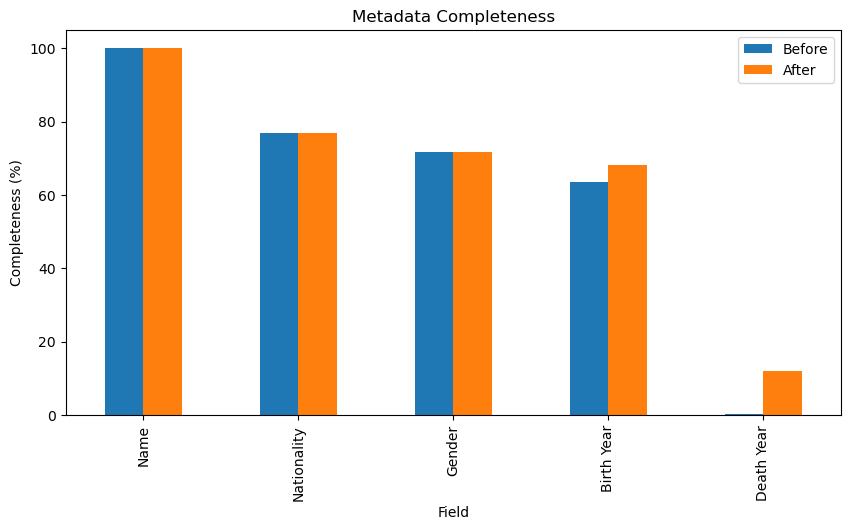

In [32]:
comparison.plot(
x="Field",
kind="bar",
figsize=(10,5)
)

plt.ylabel("Completeness (%)")

plt.title("Metadata Completeness")

plt.show()

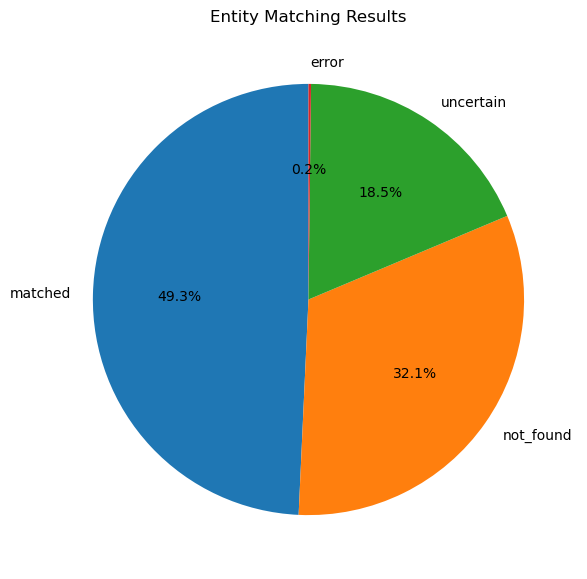

In [33]:
status=enriched["match_status"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
status.values,
labels=status.index,
autopct="%1.1f%%",
startangle=90
)

plt.title("Entity Matching Results")

plt.show()

Text(0, 0.5, 'Missing Birth Years')

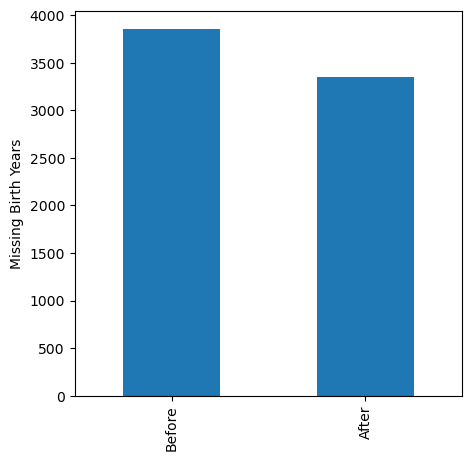

In [34]:
birth=pd.DataFrame({

"Before":[prepared["Birth Year"].isna().sum()],

"After":[enriched["Birth Year"].isna().sum()]

})

birth.T.plot(
kind="bar",
legend=False,
figsize=(5,5)
)

plt.ylabel("Missing Birth Years")


In [35]:
artists["Nationality"].value_counts().head(15)

Nationality
American               5198
German                  930
French                  839
British                 835
Italian                 531
Japanese                498
Swiss                   280
Dutch                   265
Nationality unknown     255
Austrian                243
Canadian                196
Russian                 188
Brazilian               155
Spanish                 153
Argentine               139
Name: count, dtype: int64

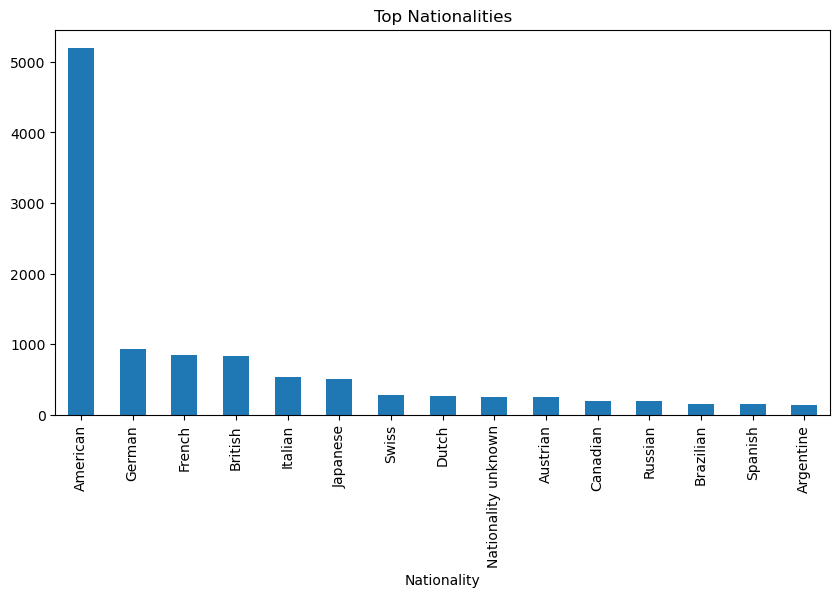

In [36]:
artists["Nationality"]\
.value_counts()\
.head(15)\
.plot(kind="bar",figsize=(10,5))

plt.title("Top Nationalities")

plt.show()

In [37]:
artists["Gender"].value_counts()

Gender
Male      9820
Female    2193
male         6
Name: count, dtype: int64

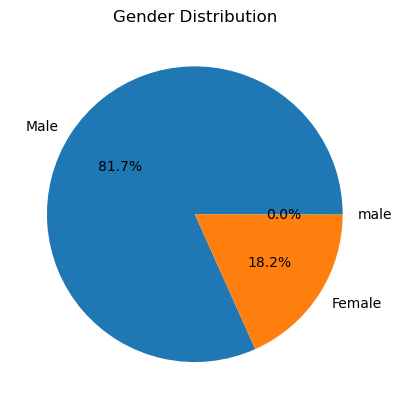

In [38]:
artists["Gender"]\
.value_counts()\
.plot(kind="pie",autopct="%1.1f%%")

plt.ylabel("")

plt.title("Gender Distribution")

plt.show()

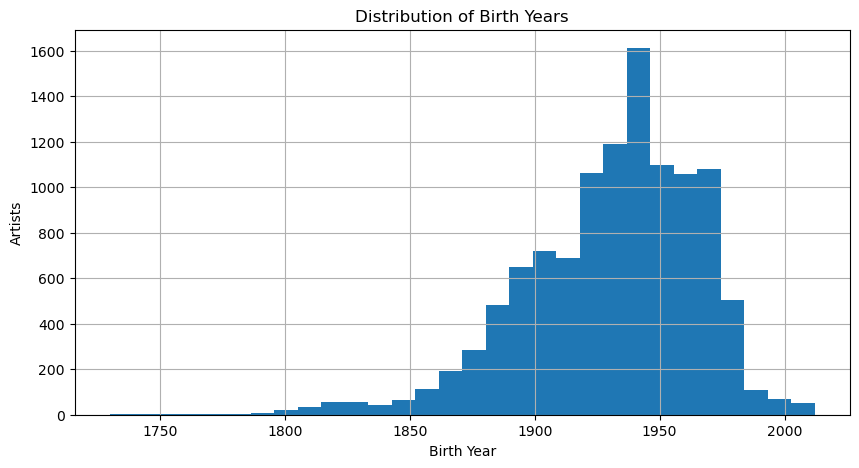

In [39]:
artists["Birth Year"]\
.dropna()\
.astype(int)\
.hist(
bins=30,
figsize=(10,5)
)

plt.title("Distribution of Birth Years")

plt.xlabel("Birth Year")

plt.ylabel("Artists")

plt.show()